# RF Fingerprinting Notebook

Notebook-first workflow for real vs complex RF encoders with synthetic fallback data.

Modes:
- `fast`: quick smoke tests (small data, short training).
- `base`: balanced default for iteration.
- `full`: longer run for stronger comparison numbers.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from config import load_config, save_scorecard_csv
from data import load_or_generate_npz
from datasets import IQDataset, TwoViewIQDataset, augment_iq, split_indices
from models import ComplexEncoder1D, RealEncoder1D, model_report
from training import (
    collect_logits,
    evaluate_identification,
    evaluate_open_set,
    evaluate_oscr,
    evaluate_verification,
    max_softmax_scores,
    extract_embeddings,
    finetune_classifier,
    pretrain_simclr,
    run_linear_probe,
    seed_everything,
    select_device,
)
from visualize import plot_history, plot_iq_views

device = select_device()

MODE = 'full'  # choose from: 'fast', 'base', 'full'

# Set an override to None to keep the value from MODE.
CONFIG_OVERRIDES = {
    'dataset_path': None,
    'output_dir': None,
    'seed': None,
    'seq_len': None,
    'n_devices': None,
    'n_sessions': None,
    'n_samples': None,
    'test_size': None,
    'val_size': None,
    'batch_size': None,
    'embed_dim': None,
    'pretrain_epochs': 20,
    'finetune_epochs': 20,
    'lr': None,
    'weight_decay': None,
    'temperature': None,
    'noise_std': None,
    'phase_jitter_rad': None,
    'time_shift': None,
    'cfo_jitter_rad': None,
    'amplitude_jitter': None,
    'aug_prob': None,
    'grad_clip': None,
    'dropout': None,
    'encoder_lr_scale': None,
    'warmup_epochs': None,
    'n_receivers': None,
    'num_workers': None,
    'n_channels': None,
    'normalize_output': False,
    'quantization_scale': None,
    'quantization_bits': None,
}

cfg = load_config(mode=MODE)
for field, value in CONFIG_OVERRIDES.items():
    if value is not None:
        setattr(cfg, field, value)
if cfg.pretrain_epochs < 1 or cfg.finetune_epochs < 1:
    raise ValueError('pretrain_epochs and finetune_epochs must each be at least 1.')

print({
    'mode': cfg.mode,
    'n_samples': cfg.n_samples,
    'batch_size': cfg.batch_size,
    'pretrain_epochs': cfg.pretrain_epochs,
    'finetune_epochs': cfg.finetune_epochs,
    'output_dir': cfg.output_dir,
})
cfg


{'mode': 'full', 'n_samples': 4000, 'batch_size': 128, 'pretrain_epochs': 20, 'finetune_epochs': 20, 'output_dir': '/home/andrewhinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full'}


RFConfig(mode='full', dataset_path='', output_dir='/home/andrewhinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full', seed=7, seq_len=256, n_devices=6, n_sessions=4, n_samples=4000, test_size=0.2, val_size=0.2, batch_size=128, embed_dim=64, pretrain_epochs=20, finetune_epochs=20, lr=0.001, weight_decay=0.0001, temperature=0.2, noise_std=0.03, phase_jitter_rad=0.03, time_shift=8, cfo_jitter_rad=0.0, amplitude_jitter=0.03, aug_prob=0.9, grad_clip=0.5, dropout=0.1, encoder_lr_scale=0.5, warmup_epochs=1, n_receivers=2, num_workers=0, n_channels=3, normalize_output=False, quantization_scale=2.0, quantization_bits=10)

In [10]:
data = load_or_generate_npz(cfg)
seed_everything(cfg.seed, deterministic=True)
print({k: v.shape for k, v in data.items() if hasattr(v, 'shape')})
metadata_unavailable = set(np.asarray(data.get('metadata_unavailable', []), dtype=str).tolist())
print('metadata_unavailable:', sorted(metadata_unavailable))
print('num_devices:', np.unique(data['device_id']).size)
if 'session_id' not in metadata_unavailable:
    print('num_sessions:', np.unique(data['session_id']).size)

{'iq': (4000, 256), 'device_id': (4000,), 'session_id': (4000,), 'receiver_id': (4000,), 'channel_id': (4000,), 'waveform_id': (4000,), 'snr_db': (4000,)}
metadata_unavailable: []
num_devices: 6
num_sessions: 4


In [11]:
all_devices = np.sort(np.unique(data['device_id']))
if all_devices.size < 2:
    raise ValueError('Need at least two devices for known/unknown open-set evaluation.')
known_devices = all_devices[:-1]
unknown_devices = all_devices[-1:]
known_mask = np.isin(data['device_id'], known_devices)
unknown_mask = np.isin(data['device_id'], unknown_devices)
known_indices = np.flatnonzero(known_mask)
unknown_indices = np.flatnonzero(unknown_mask)
label_map = {int(label): i for i, label in enumerate(known_devices)}
known_labels = np.asarray([label_map[int(label)] for label in data['device_id'][known_indices]], dtype=np.int64)
# Prefer a true session-held-out split; otherwise combine every available nuisance field.
if 'session_id' not in metadata_unavailable:
    known_splits = split_indices(len(known_indices), cfg.test_size, cfg.val_size, cfg.seed, session_ids=data['session_id'][known_indices], group_by='session')
    split_strategy = 'session-held-out'
else:
    nuisance_names = [name for name in ('receiver_id', 'channel_id', 'waveform_id') if name in data and name not in metadata_unavailable]
    if not nuisance_names:
        raise ValueError(f'No session or nuisance metadata available; unavailable={sorted(metadata_unavailable)}')
    # split_indices accepts one-dimensional keys; encode the tuple without collisions.
    group_ids = np.asarray(['|'.join(map(str, values)) for values in zip(*(data[name][known_indices].tolist() for name in nuisance_names))], dtype=str)
    known_splits = split_indices(len(known_indices), cfg.test_size, cfg.val_size, cfg.seed, group_ids=group_ids)
    split_strategy = 'combined-nuisance-held-out'
print('split_strategy:', split_strategy, 'known_devices:', known_devices.tolist(), 'unknown_devices:', unknown_devices.tolist())
train_indices = known_indices[known_splits['train']]
val_indices = known_indices[known_splits['val']]
test_indices = known_indices[known_splits['test']]
train_ds = IQDataset(data['iq'][train_indices], known_labels[known_splits['train']])
val_ds = IQDataset(data['iq'][val_indices], known_labels[known_splits['val']])
test_ds = IQDataset(data['iq'][test_indices], known_labels[known_splits['test']])
unknown_ds = IQDataset(data['iq'][unknown_indices], np.zeros(len(unknown_indices), dtype=np.int64))
num_classes = len(known_devices)
split_summary = {}
for name, indices in known_splits.items():
    labels_in_split = known_labels[indices]
    split_summary[name] = {
        'n_samples': int(len(indices)),
        'sample_fraction': float(len(indices) / len(known_indices)),
        'class_count': int(np.unique(labels_in_split).size),
        'class_coverage': float(np.unique(labels_in_split).size / num_classes),
    }
missing_classes = {name: sorted(set(range(num_classes)) - set(np.unique(known_labels[indices]).tolist())) for name, indices in known_splits.items()}
missing_classes = {name: labels for name, labels in missing_classes.items() if labels}
if missing_classes:
    raise ValueError(f'Grouped split is missing known classes: {missing_classes}. Adjust split sizes or grouping metadata.')
print('grouped split semantics: requested fractions apply to groups; actual sample fractions and class coverage:', split_summary)
len(train_ds), len(val_ds), len(test_ds), len(unknown_ds), num_classes

split_strategy: session-held-out known_devices: [0, 1, 2, 3, 4] unknown_devices: [5]
grouped split semantics: requested fractions apply to groups; actual sample fractions and class coverage: {'train': {'n_samples': 1703, 'sample_fraction': 0.5107978404319136, 'class_count': 5, 'class_coverage': 1.0}, 'val': {'n_samples': 816, 'sample_fraction': 0.244751049790042, 'class_count': 5, 'class_coverage': 1.0}, 'test': {'n_samples': 815, 'sample_fraction': 0.24445110977804438, 'class_count': 5, 'class_coverage': 1.0}}


(1703, 816, 815, 666, 5)

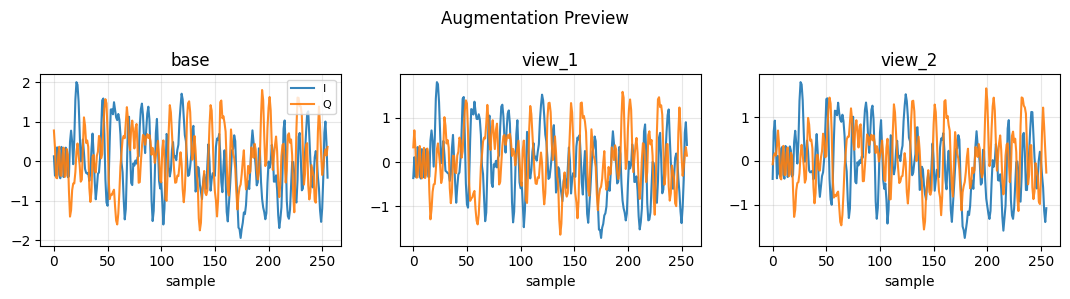

In [12]:
sample = data['iq'][0]
v1 = augment_iq(sample, noise_std=cfg.noise_std, phase_jitter_rad=cfg.phase_jitter_rad, time_shift=cfg.time_shift)
v2 = augment_iq(sample, noise_std=cfg.noise_std, phase_jitter_rad=cfg.phase_jitter_rad, time_shift=cfg.time_shift)
_ = plot_iq_views(sample, [v1, v2], title='Augmentation Preview')


In [13]:
class EpochVaryingTwoViewDataset(TwoViewIQDataset):
    """Deterministic two-view data whose augmentation epoch advances per full pass."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._access_count = 0

    def __getitem__(self, index):
        self.set_epoch(self._access_count // max(len(self), 1))
        self._access_count += 1
        return super().__getitem__(index)

two_view_ds = EpochVaryingTwoViewDataset(data['iq'][train_indices], cfg, seed=cfg.seed)

def run_pipeline(name):
    seed = cfg.seed
    seed_everything(seed, deterministic=True)
    if name == 'real':
        encoder = RealEncoder1D(embed_dim=cfg.embed_dim)
    else:
        encoder = ComplexEncoder1D(embed_dim=cfg.embed_dim)

    # pretrain_simclr owns the epoch loop; the dataset advances its deterministic
    # augmentation epoch on each full pass, preserving matched two-view augmentation.
    pre_hist = pretrain_simclr(encoder, two_view_ds, cfg, device, seed=seed, deterministic=True)
    probe_metrics = run_linear_probe(encoder.to(device), train_ds, test_ds, device)

    ft_model, ft_hist = finetune_classifier(
        encoder=encoder.to(device),
        train_dataset=train_ds,
        val_dataset=val_ds,
        num_classes=num_classes,
        cfg=cfg,
        device=device,
    )

    test_logits, test_labels = collect_logits(ft_model, test_ds, device)
    unknown_logits, _ = collect_logits(ft_model, unknown_ds, device)
    eval_metrics = evaluate_identification(test_logits, test_labels)
    test_embeddings, _ = extract_embeddings(ft_model.encoder, test_ds, device)
    verification = evaluate_verification(test_embeddings, test_labels, seed=seed)
    os_metrics = evaluate_open_set(test_logits, unknown_logits)
    oscr_metrics = evaluate_oscr(test_logits, test_labels, unknown_logits)

    report = model_report(ft_model, input_shape=(1, cfg.seq_len))
    print(f'{name} model_report:', report)

    row = {
        'encoder': name,
        'pretrain_final_loss': float(pre_hist['loss'][-1]) if pre_hist.get('loss') else float('nan'),
        'probe_acc': float(probe_metrics['probe_acc']),
        'identification_acc': float(eval_metrics['acc']),
        'identification_f1_macro': float(eval_metrics['f1_macro']),
        'verification_auroc': float(verification['auroc']),
        'verification_eer': float(verification['eer']),
        'verification_tpr_at_far_0.01': float(verification['tpr_at_far']['tpr_at_far_0.01']),
        'verification_tpr_at_far_0.05': float(verification['tpr_at_far']['tpr_at_far_0.05']),
        'open_set_auroc': float(os_metrics['auroc']),
        'open_set_oscr_auc': float(oscr_metrics['oscr_auc']),
        'comparison_mode': 'matched embed_dim/channels/pooling; real-scalar capacity reported',
        'real_scalar_parameters': int(report['real_scalar_parameters']),
    }
    details = {
        'test_logits': test_logits,
        'test_labels': test_labels,
        'unknown_logits': unknown_logits,
        'verification': verification,
        'open_set': os_metrics,
        'oscr': oscr_metrics,
        'report': report,
    }
    return row, pre_hist, ft_hist, details

real_row, real_pre_hist, real_ft_hist, real_details = run_pipeline('real')
complex_row, complex_pre_hist, complex_ft_hist, complex_details = run_pipeline('complex')
scorecard = [real_row, complex_row]
scorecard

real model_report: {'parameters': 36133, 'trainable_parameters': 36133, 'real_scalar_parameters': 36133, 'trainable_real_scalar_parameters': 36133, 'real_conv_macs': 1368064, 'complex_conv_macs': 0, 'conv_macs': 1368064, 'linear_macs': 4416, 'macs': 1372480, 'output_shape': (1, 5)}
complex model_report: {'parameters': 35912, 'trainable_parameters': 35912, 'real_scalar_parameters': 67336, 'trainable_real_scalar_parameters': 67336, 'real_conv_macs': 0, 'complex_conv_macs': 5357568, 'conv_macs': 5357568, 'linear_macs': 4416, 'macs': 5361984, 'output_shape': (1, 5)}


[{'encoder': 'real',
  'pretrain_final_loss': 1.563300758600235,
  'probe_acc': 0.23558282208588957,
  'identification_acc': 0.27607361963190186,
  'identification_f1_macro': 0.2594791737423621,
  'verification_auroc': 0.536793608,
  'verification_eer': 0.47702,
  'verification_tpr_at_far_0.01': 0.02218,
  'verification_tpr_at_far_0.05': 0.0726,
  'open_set_auroc': 0.5564398754582804,
  'open_set_oscr_auc': 0.18040494482212274,
  'comparison_mode': 'matched embed_dim/channels/pooling; real-scalar capacity reported',
  'real_scalar_parameters': 36133},
 {'encoder': 'complex',
  'pretrain_final_loss': 1.618261741740363,
  'probe_acc': 0.27607361963190186,
  'identification_acc': 0.3067484662576687,
  'identification_f1_macro': 0.2852613882130639,
  'verification_auroc': 0.5149705971999999,
  'verification_eer': 0.48934,
  'verification_tpr_at_far_0.01': 0.0104,
  'verification_tpr_at_far_0.05': 0.05216,
  'open_set_auroc': 0.516348864201625,
  'open_set_oscr_auc': 0.17030527459975314,
  

## Post-training metrics

The plots below compare representation learning, closed-set identification, same-device verification, and rejection of unseen devices. Lower SimCLR loss and verification EER are better; higher accuracy, macro-F1, AUROC, TPR-at-FAR, and OSCR AUC are better.

- **SimCLR loss:** whether two augmented views of the same IQ sample are pulled together while other samples are separated.
- **Validation accuracy:** known-device accuracy used during fine-tuning checkpoint selection.
- **Identification accuracy:** fraction of known-device test samples assigned the correct device.
- **Macro-F1:** average device F1, giving each device equal weight despite imbalance.
- **Verification AUROC:** ability to distinguish same-device from different-device pairs over all thresholds.
- **EER:** approximate point where false-accept and false-reject rates are equal; lower is better.
- **TPR at FAR:** genuine-device acceptance rate at a specified false-accept rate; higher is better.
- **Open-set AUROC:** ability to distinguish enrolled devices from unseen devices using classifier confidence.
- **OSCR AUC:** tradeoff between correctly classifying known devices and rejecting unknown devices.
- **Confidence distributions:** unknown devices should generally have lower max-softmax confidence than known devices.

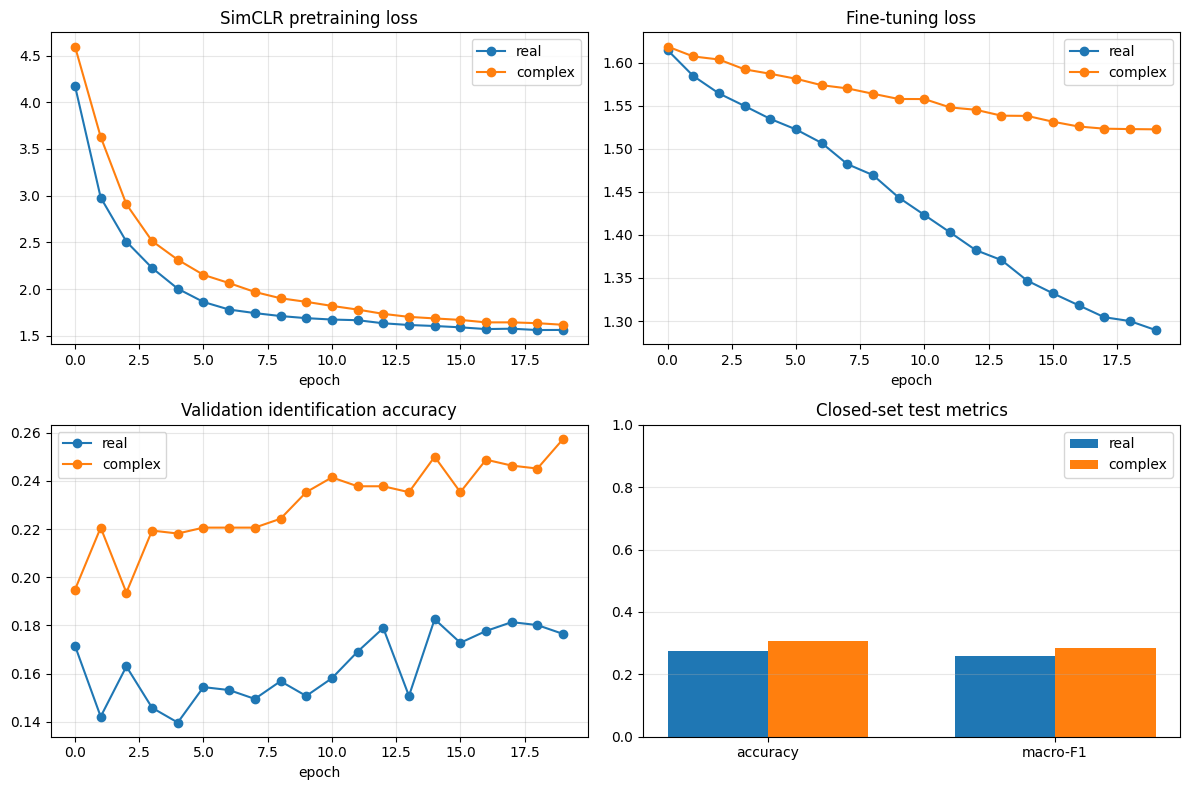

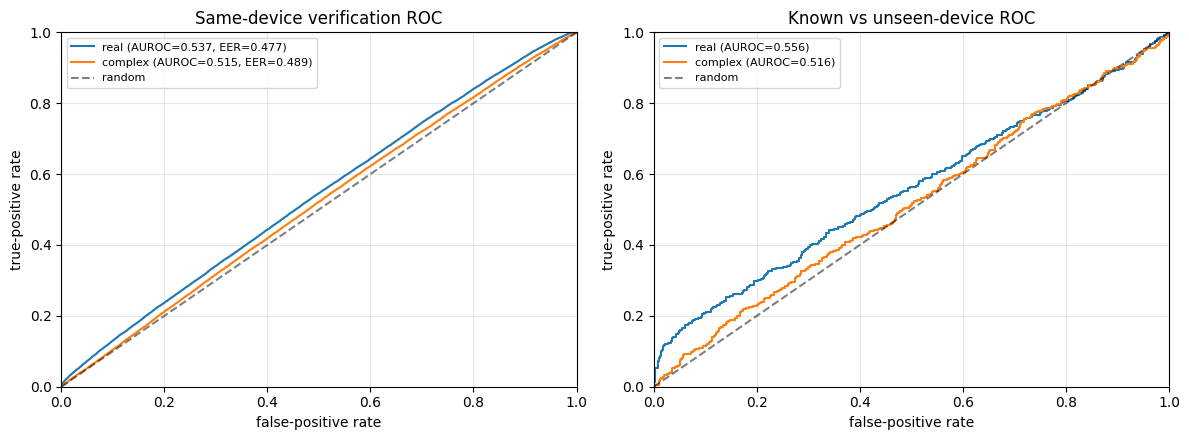

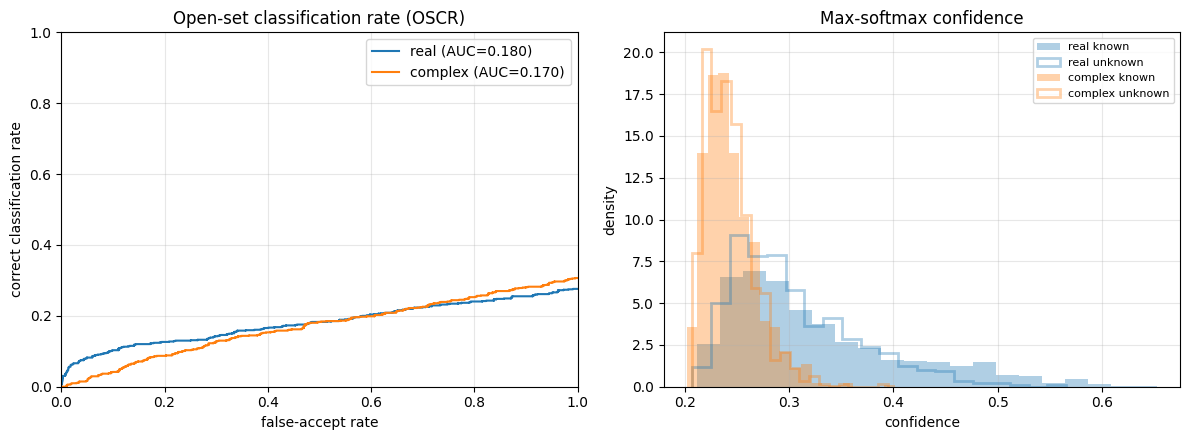

In [14]:
results = {'real': (real_pre_hist, real_ft_hist, real_details), 'complex': (complex_pre_hist, complex_ft_hist, complex_details)}
colors = {'real': 'tab:blue', 'complex': 'tab:orange'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for name, (pre_hist, ft_hist, _) in results.items():
    for ax, history, key, label in ((axes[0, 0], pre_hist, 'loss', 'pretraining loss'), (axes[0, 1], ft_hist, 'loss', 'fine-tuning loss'), (axes[1, 0], ft_hist, 'val_acc', 'validation accuracy')):
        values = history.get(key, [])
        if values:
            ax.plot(values, marker='o', label=name, color=colors[name])
        else:
            print(f'{name}: no {label} history to plot')
axes[0, 0].set_title('SimCLR pretraining loss')
axes[0, 1].set_title('Fine-tuning loss')
axes[1, 0].set_title('Validation identification accuracy')
for ax in axes.flat[:3]:
    ax.set_xlabel('epoch')
    ax.grid(alpha=0.3)
    if ax.lines:
        ax.legend()
metric_names = ['identification_acc', 'identification_f1_macro']
x = np.arange(len(metric_names))
width = 0.35
for i, name in enumerate(('real', 'complex')):
    values = [scorecard[i][metric] for metric in metric_names]
    axes[1, 1].bar(x + (i - 0.5) * width, values, width, label=name, color=colors[name])
axes[1, 1].set_xticks(x, ['accuracy', 'macro-F1'])
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Closed-set test metrics')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (_, _, details) in results.items():
    verification = details['verification']
    open_set = details['open_set']
    if len(verification.get('fpr', [])) and len(verification.get('tpr', [])):
        axes[0].plot(verification['fpr'], verification['tpr'], label=f"{name} (AUROC={verification['auroc']:.3f}, EER={verification['eer']:.3f})", color=colors[name])
    else:
        print(f'{name}: no verification ROC data to plot')
    if len(open_set.get('fpr', [])) and len(open_set.get('tpr', [])):
        axes[1].plot(open_set['fpr'], open_set['tpr'], label=f"{name} (AUROC={open_set['auroc']:.3f})", color=colors[name])
    else:
        print(f'{name}: no open-set ROC data to plot')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
axes[0].set_title('Same-device verification ROC')
axes[1].set_title('Known vs unseen-device ROC')
for ax in axes:
    ax.set_xlabel('false-positive rate')
    ax.set_ylabel('true-positive rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    if ax.lines:
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (_, _, details) in results.items():
    oscr = details['oscr']
    if len(oscr.get('far', [])) and len(oscr.get('ccr', [])):
        axes[0].plot(oscr['far'], oscr['ccr'], label=f"{name} (AUC={oscr['oscr_auc']:.3f})", color=colors[name])
    else:
        print(f'{name}: no OSCR data to plot')
    if details['test_logits'].size and details['unknown_logits'].size:
        id_conf = max_softmax_scores(details['test_logits'])
        ood_conf = max_softmax_scores(details['unknown_logits'])
        axes[1].hist(id_conf, bins=20, alpha=0.35, density=True, label=f'{name} known', color=colors[name])
        axes[1].hist(ood_conf, bins=20, alpha=0.35, density=True, histtype='step', linewidth=2, label=f'{name} unknown', color=colors[name])
    else:
        print(f'{name}: no logits for confidence distributions')
axes[0].set_title('Open-set classification rate (OSCR)')
axes[0].set_xlabel('false-accept rate')
axes[0].set_ylabel('correct classification rate')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
if axes[0].lines:
    axes[0].legend()
axes[1].set_title('Max-softmax confidence')
axes[1].set_xlabel('confidence')
axes[1].set_ylabel('density')
axes[1].grid(alpha=0.3)
if axes[1].patches or axes[1].lines:
    axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [15]:
summary_columns = [
    'encoder', 'identification_acc', 'identification_f1_macro',
    'verification_auroc', 'verification_eer',
    'verification_tpr_at_far_0.01', 'verification_tpr_at_far_0.05',
    'open_set_auroc', 'open_set_oscr_auc',
]
metric_summary = [{key: row[key] for key in summary_columns} for row in scorecard]
metric_summary

[{'encoder': 'real',
  'identification_acc': 0.27607361963190186,
  'identification_f1_macro': 0.2594791737423621,
  'verification_auroc': 0.536793608,
  'verification_eer': 0.47702,
  'verification_tpr_at_far_0.01': 0.02218,
  'verification_tpr_at_far_0.05': 0.0726,
  'open_set_auroc': 0.5564398754582804,
  'open_set_oscr_auc': 0.18040494482212274},
 {'encoder': 'complex',
  'identification_acc': 0.3067484662576687,
  'identification_f1_macro': 0.2852613882130639,
  'verification_auroc': 0.5149705971999999,
  'verification_eer': 0.48934,
  'verification_tpr_at_far_0.01': 0.0104,
  'verification_tpr_at_far_0.05': 0.05216,
  'open_set_auroc': 0.516348864201625,
  'open_set_oscr_auc': 0.17030527459975314}]

In [16]:
scorecard_path = f"{cfg.output_dir}/scorecard.csv"
save_scorecard_csv(scorecard_path, scorecard)
print('scorecard_csv:', scorecard_path)
scorecard

scorecard_csv: /home/andrewhinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full/scorecard.csv


[{'encoder': 'real',
  'pretrain_final_loss': 1.563300758600235,
  'probe_acc': 0.23558282208588957,
  'identification_acc': 0.27607361963190186,
  'identification_f1_macro': 0.2594791737423621,
  'verification_auroc': 0.536793608,
  'verification_eer': 0.47702,
  'verification_tpr_at_far_0.01': 0.02218,
  'verification_tpr_at_far_0.05': 0.0726,
  'open_set_auroc': 0.5564398754582804,
  'open_set_oscr_auc': 0.18040494482212274,
  'comparison_mode': 'matched embed_dim/channels/pooling; real-scalar capacity reported',
  'real_scalar_parameters': 36133},
 {'encoder': 'complex',
  'pretrain_final_loss': 1.618261741740363,
  'probe_acc': 0.27607361963190186,
  'identification_acc': 0.3067484662576687,
  'identification_f1_macro': 0.2852613882130639,
  'verification_auroc': 0.5149705971999999,
  'verification_eer': 0.48934,
  'verification_tpr_at_far_0.01': 0.0104,
  'verification_tpr_at_far_0.05': 0.05216,
  'open_set_auroc': 0.516348864201625,
  'open_set_oscr_auc': 0.17030527459975314,
  